<a href="https://colab.research.google.com/github/grupos4g4/PROJAPLIC4/blob/main/cd_projeto_aplicado_IV_entrega_4_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/02**


# **Entrega 4**

---

# **Previsão da Evasão no Ensino Superior EaD (2014-2024) com Projeções até 2026**
---

In [ ]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Anderson Aparecido da Silva Alves, 10347602' #@param {type:"string"}
Aluno2 = 'Andreia Domingos dos Santos, 10288503' #@param {type:"string"}
Aluno3 = 'Gerson Soares Rodrigues, 10423804' #@param {type:"string"}
Aluno4 = 'Samuel Bonfim da Silva, 10423569' #@param {type:"string"}


# **Resumo**

Este trabalho apresenta a quarta etapa do Projeto Aplicado IV, cujo objetivo é modelar e prever a taxa de evasão de cursos de educação superior no Brasil utilizando dados do Censo da Educação Superior (INEP). Após a consolidação da base de dados, realizamos uma análise exploratória detalhada (EDA), destacando padrões por ano e modalidade (presencial/EaD). Em seguida, desenvolvemos um modelo preditivo baseado em redes neurais recorrentes do tipo LSTM, incorporando embeddings para variáveis categóricas e séries temporais anuais entre 2014 e 2024. Os resultados indicam que o modelo é capaz de capturar tendências estruturais da evasão, especialmente o comportamento crescente na modalidade EaD. Também avaliamos a capacidade preditiva na base de teste (2023–2024) e realizamos uma extrapolação exploratória para os anos subsequentes. Os achados reforçam a utilidade de técnicas de deep learning na compreensão de dinâmicas educacionais e sugerem caminhos de aprimoramento para pesquisas futuras.

# **Introdução**

A educação superior brasileira tem passado, entre 2014 e 2024, por mudanças estruturais que afetam diretamente os padrões de matrícula, permanência e conclusão dos estudantes. Entre essas transformações destacam-se a expansão acelerada da modalidade a distância (EaD), o processo de recomposição das matrículas após a pandemia de COVID-19 e ajustes na rede de instituições e cursos. O Censo da Educação Superior, produzido anualmente pelo Instituto Nacional de Estudos e Pesquisas (Inep), é a principal fonte para acompanhar essas dinâmicas, oferecendo dados essenciais para análises acadêmicas, planejamento institucional e formulação de políticas públicas (BRASIL, 2024). Relatórios complementares, como o Censo EAD.BR 2023/2024, também evidenciam que práticas de gestão, mediação pedagógica e uso de tecnologias influenciam diretamente a permanência dos estudantes, especialmente na modalidade EaD (ABED, 2024). Além disso, estudos nacionais e internacionais reforçam que a evasão resulta de múltiplos fatores e que modelos preditivos podem apoiar intervenções mais precisas (OLIVEIRA et al., 2021; TAMADA, 2022; NGUYEN THI CAM; SARLAN; ARSHAD, 2024; TALEBI; TORABI; DANESHPOUR, 2024; VOGHOEI et al., 2023; SEMESP, 2025).

Esse contexto motivou o desenvolvimento do presente trabalho, cujo objetivo geral é analisar tendências e projeções da taxa de evasão no ensino superior brasileiro utilizando séries históricas derivadas dos microdados do Censo da Educação Superior no período de 2014 a 2024, com aplicação de técnicas de aprendizado profundo, especialmente redes LSTM. Para atingir esse propósito, o estudo compreende etapas integradas que incluem: a consolidação e preparação da base anual contendo matrículas, ingressantes, concluintes e situações acadêmicas; o cálculo da taxa de evasão por curso e modalidade; a realização de análise exploratória (EDA) para identificação de padrões e rupturas; a estruturação de janelas temporais adequadas ao modelo; e o treinamento, avaliação e interpretação de um modelo LSTM com embeddings para variáveis categóricas, capaz de gerar previsões a partir do comportamento histórico das séries.

A base de dados utilizada *dataset_inep.csv* foi construída a partir dos microdados oficiais do Inep, englobando informações agregadas por ano, instituição, curso e modalidade entre 2014 e 2024. Essa organização possibilita análises consistentes e reprodutíveis, além de subsidiar a modelagem temporal necessária para capturar tendências da evasão no período.

A justificativa para este estudo reside tanto na relevância técnica quanto na relevância social do tema. Do ponto de vista técnico, o trabalho aplica conceitos e métodos discutidos no componente curricular, envolvendo pré-processamento, análise exploratória e modelagem preditiva com redes neurais recorrentes, em consonância com a literatura recente sobre predição de evasão (NGUYEN THI CAM; SARLAN; ARSHAD, 2024; TALEBI; TORABI; DANESHPOUR, 2024). No plano social, a construção de diagnósticos quantitativos e projeções a partir de dados oficiais permite identificar padrões críticos, apoiar decisões institucionais e contribuir para políticas mais eficazes de permanência estudantil. Ao integrar análise estatística, técnicas de inteligência artificial e dados públicos de larga escala, o estudo busca apoiar o enfrentamento da evasão e promover uma gestão educacional mais eficiente e alinhada às necessidades contemporâneas do sistema de ensino superior (ABED, 2024; SEMESP, 2025).

# **Referencial Teórico**

Estudos apontam que a evasão tende a ocorrer quando há ruptura na trajetória formativa, falta de suporte institucional ou dificuldades de adaptação ao modelo pedagógico — especialmente na modalidade a distância, onde aspectos como motivação e autonomia exercem papel determinante (OLIVEIRA et al., 2021). Nesse contexto, o acompanhamento sistemático das taxas de evasão e a construção de modelos capazes de identificar padrões temporais tornam-se estratégias importantes para subsidiar políticas de permanência.

No campo da Ciência de Dados aplicada à educação, diferentes abordagens têm sido empregadas para previsão ou detecção precoce de evasão. Métodos estatísticos tradicionais, como regressão linear e modelos ARIMA, já foram amplamente utilizados em séries históricas de indicadores educacionais, mas apresentam limitações quando há padrões não lineares, mudanças estruturais ou forte dependência temporal (TAMADA, 2022). Em ambientes de ensino online, modelos supervisionados como Random Forest, Gradient Boosting e SVM vêm sendo aplicados para classificar estudantes em risco de evasão, mas sua capacidade de capturar relações sequenciais entre eventos ou anos é limitada (VOGHOEI et al., 2023).

Com o avanço do aprendizado profundo, modelos de redes neurais recorrentes (RNNs), especialmente as *Long Short-Term Memory* (LSTM), passaram a ser amplamente empregados para análise temporal da evasão educacional. As LSTMs são capazes de reter informações de longo prazo por meio de seus mecanismos internos de memória, superando limitações de RNNs tradicionais. Nguyen Thi Cam, Sarlan e Arshad (2024), por exemplo, propuseram um modelo híbrido que integra LSTMs com máquinas de vetor de suporte semissupervisionadas para identificar risco de evasão, demonstrando maior precisão em comparação a abordagens puramente supervisionadas. Em outro estudo relevante, Talebi, Torabi e Daneshpour (2024) utilizaram modelos ensemble combinando CNN e LSTM para previsão de evasão em cursos massivos (MOOCs), reforçando que modelos híbridos tendem a capturar tanto padrões temporais quanto características contextuais do estudante.

Embora essas abordagens mostrem alto desempenho, algumas limitações são recorrentes: necessidade de bases históricas extensas, dificuldade de interpretação dos resultados e sensibilidade a dados faltantes ou desbalanceados. Além disso, a maior parte dos trabalhos internacionais concentra-se em ambientes de plataformas digitais de aprendizagem, cuja granularidade de dados (logs, interações, tempo de acesso) difere do contexto brasileiro baseado em microdados educacionais anuais.

Nesse sentido, aplica-se neste estudo uma solução alinhada às tendências contemporâneas do campo: modelos LSTM para previsão de séries temporais baseadas em indicadores anuais de evasão. O uso de embeddings para variáveis categóricas tais como: modalidade, tipo de instituição e região — permite que o modelo represente características estruturais da educação superior brasileira de forma eficiente e não esparsa. Essa abordagem junta a força das LSTMs para lidar com dependências ao longo do tempo, com uma maior capacidade de entender o significado das variáveis institucionais, tornando o modelo mais expressivo.

Em comparação com alternativas tradicionais (ETS, ARIMA e regressões lineares), modelos baseados em aprendizado profundo apresentam vantagens ao lidar com relações não lineares, múltiplas dimensões e padrões temporais complexos. Por outro lado, exigem maior poder computacional, apresentam menor interpretabilidade e requerem maior cuidado no pré-processamento da base. Ainda assim, conforme apontam as análises setoriais do Censo da Educação Superior (BRASIL, 2024), do Censo EAD.BR (ABED, 2024) e do Mapa do Ensino Superior no Brasil (SEMESP, 2025), a necessidade de modelos mais robustos para compreensão da evasão é crescente, o que reforça a validade da abordagem adotada.

Dessa forma, este trabalho destaca a relevância de técnicas modernas de predição baseadas em séries temporais e aprendizado profundo, evidenciando que a adoção de modelos LSTM representa uma alternativa adequada para capturar tendências da evasão no ensino superior brasileiro no período de 2014 a 2024.



# **Diagrama de Solução**

O processo desenvolvido para previsão da taxa de evasão no ensino superior, considerando o período de 2014 a 2024, foi estruturado em um pipeline composto por etapas sequenciais e interdependentes. O objetivo é transformar os microdados brutos do Censo da Educação Superior em séries temporais consistentes e, a partir delas, treinar um modelo baseado em redes neurais LSTM capaz de antecipar padrões de evasão. A seguir, apresenta-se o fluxo completo da solução implementada.

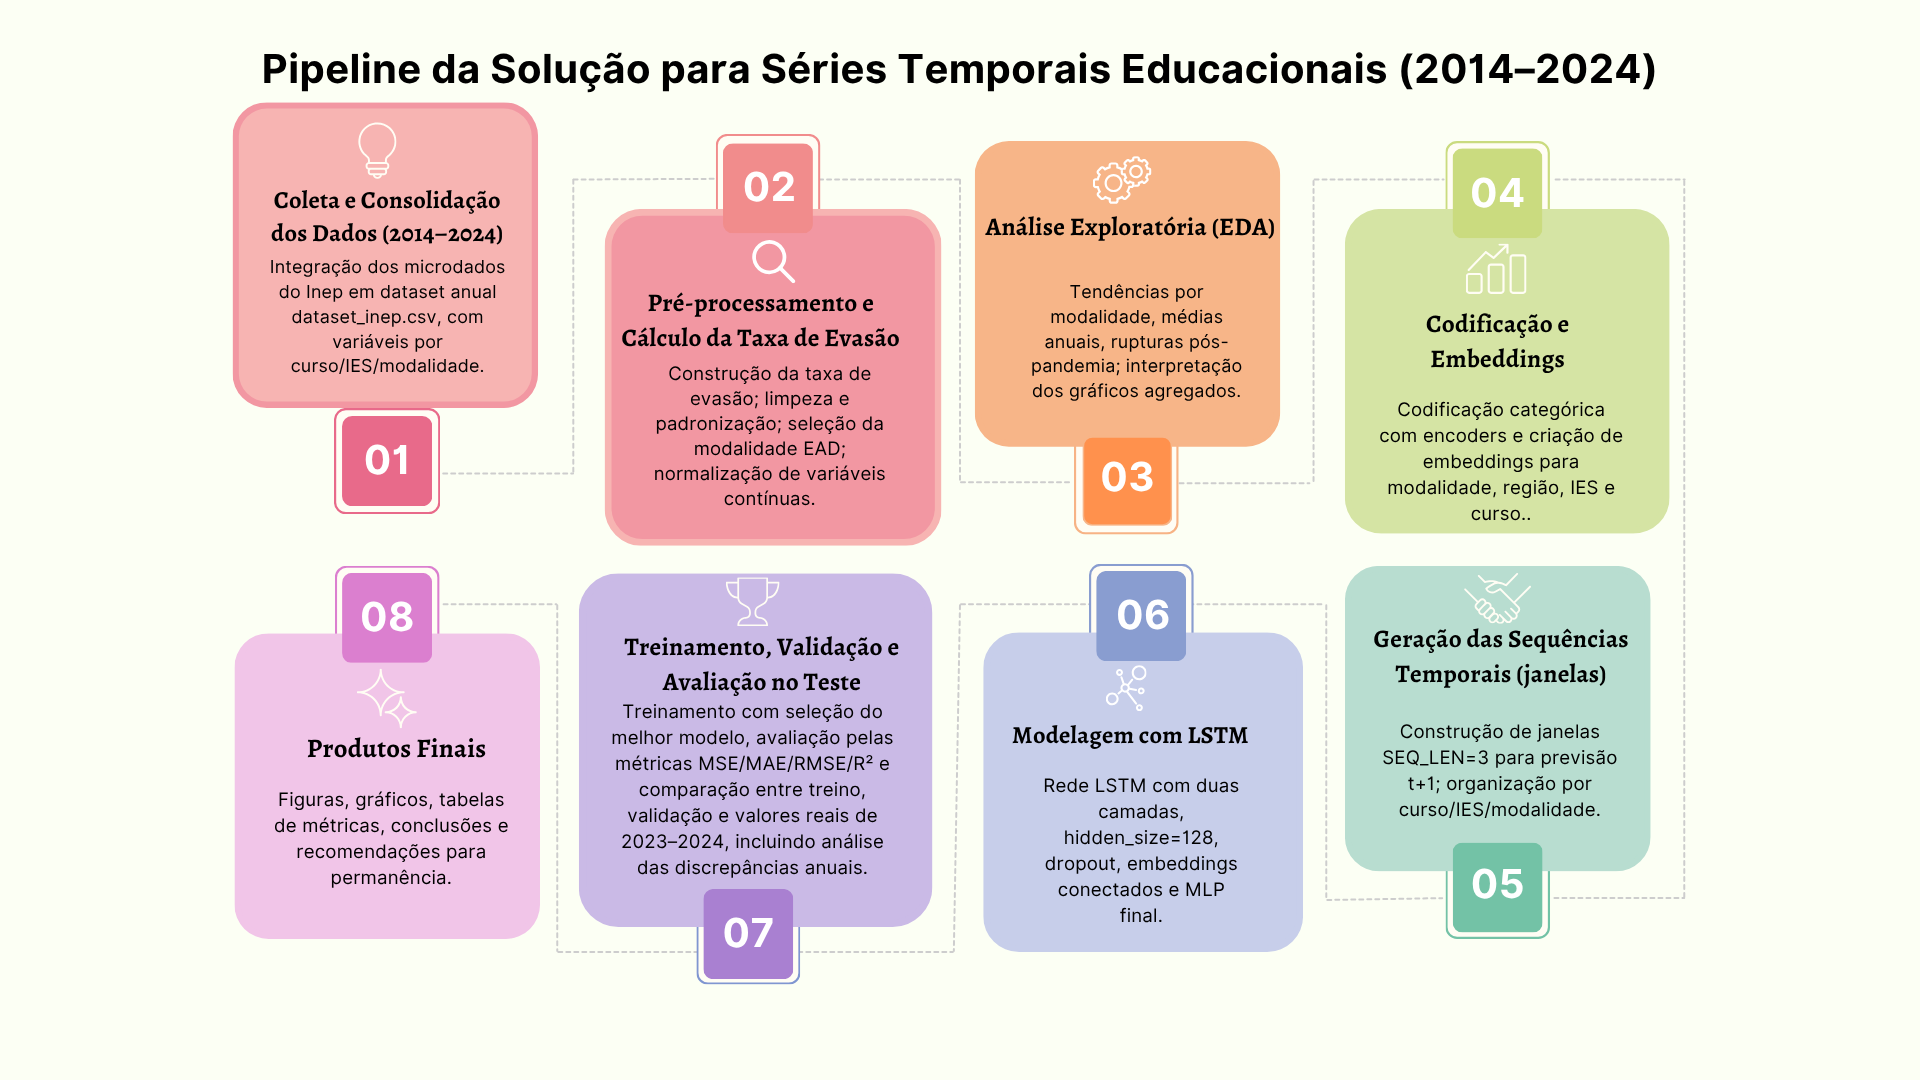

## 1. Coleta e Consolidação dos Dados ##

Os microdados oficiais do Inep são integrados e organizados no arquivo consolidado dataset_inep.csv, contendo informações anuais por curso, instituição e modalidade. Nessa etapa, são selecionadas variáveis essenciais (matrículas, ingressantes, concluintes e situações acadêmicas) e estruturados os dados de forma padronizada e consistente para permitir análises temporais confiáveis.

## 2. Pré-processamento e Construção da Taxa de Evasão ##

As variáveis de situação acadêmica (trancamento, desligamento, transferência e óbito) são agregadas para compor a evasão total. Em seguida, calcula-se a taxa de evasão como proporção entre evasão total e matrículas válidas. Registros inconsistentes, como aqueles com matrículas iguais a zero, são removidos. A base também passa por limpeza, padronização e filtragem da modalidade EAD, além de normalização das variáveis contínuas quando necessário.

## 3. Análise Exploratória (EDA) ##

Esta etapa inclui análise interpretativa dos gráficos gerados. São examinadas tendências anuais por modalidade, médias agregadas, possíveis rupturas no período pós-pandemia e diferenças estruturais entre EaD e presencial. Essa análise fundamenta a compreensão dos padrões que o modelo deverá captar e ajuda a validar a coerência dos dados antes da modelagem.

## 04. Codificação e Embeddings ##

As variáveis categóricas (modalidade, tipo de instituição, região, organização acadêmica, entre outras) são transformadas por meio de encoders e posteriormente representadas em vetores densos usando embeddings. Essa abordagem melhora a capacidade do modelo de captar características institucionais e reduz a esparsidade que ocorreria com métodos tradicionais de codificação.

## 05. Geração das Sequências Temporais (Janelas) ##

A base é ordenada por curso/IES/modalidade e ano, e são construídas janelas temporais do tipo sliding window com tamanho fixo (SEQ_LEN = 3). Cada janela representa um trecho da série histórica, sendo o último valor a variável alvo empregada na previsão t+1. Essa etapa prepara adequadamente os dados para utilização na rede LSTM e mantém a coerência temporal.

## 06. Modelagem com LSTM ##

A arquitetura implementada integra os embeddings das variáveis categóricas com variáveis contínuas padronizadas, alimentando uma rede LSTM composta por duas camadas, hidden_size = 128 e dropout ajustado. Após a LSTM, uma MLP final realiza a regressão da taxa prevista. Essa arquitetura atende à recomendação do professor de aumentar a profundidade do modelo e ajustar o número de unidades.

## 07. Treinamento, Validação e Avaliação no Teste ##

O modelo é treinado com o otimizador Adam e função de perda MSE. O melhor modelo é salvo via checkpoint. Métricas como MSE, MAE, RMSE e R² são acompanhadas para avaliar o desempenho nas etapas de treino e validação. Após o treinamento, o modelo é aplicado à base de teste (2023–2024), permitindo comparar valores reais e previstos, identificar discrepâncias e analisar o comportamento agregado por ano.

## 08. Produtos Finais ##

A etapa final consolida métricas, gráficos, tabelas e interpretações dos resultados, incluindo comparações Real × Previsto e sínteses visuais. Esses produtos sustentam a discussão sobre tendências, limitações, impactos e recomendações práticas relacionadas à evasão, além de orientar decisões para ações de permanência estudantil.

# **EDA e Pré-processamento dos dados**

(Exploração, discussão da base, preparação, limpeza, transformações, encoders, normalização e janelas temporais)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Célula 1: *Imports e configurações básicas* ###

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reprodutibilidade
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cpu


### *Célula 2: Carregamento dos dados* ###

In [ ]:
CAMINHO_TREINO = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_train_2014_2020.csv"
CAMINHO_VAL    = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_val_2021_2022.csv"
CAMINHO_TESTE  = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_test_2023_2024.csv"

MODALIDADE_EAD = 1

# Colunas contínuas (features numéricas)
CONT_COLS = [
    'QT_MAT',
    'QT_ING',
    'QT_ING_FEM',
    'QT_ING_MASC',
    'QT_SIT_TRANCADA',
    'QT_SIT_DESVINCULADO',
    'QT_SIT_TRANSFERIDO',
    'QT_SIT_FALECIDO',
    'QT_ING_PROCESCPUBLICA',
    'QT_ING_PROCESCPRIVADA',
]

# Colunas categóricas (para embeddings)
CAT_COLS = [
    'Modalidade',
    'Rede',
    'CO_REGIAO',
    'CO_UF',
    'CO_MUNICIPIO',
    'CO_CINE_ROTULO_id',
]

# Ano e agrupamento para séries temporais
YEAR_COL   = "NU_ANO_CENSO"
GROUP_COLS = ['CO_IES', 'CO_CINE_ROTULO_id', 'Modalidade']

# Coluna alvo
TARGET_COL = "TAXA_EVASAO"

# Tamanho da janela temporal
SEQ_LEN = 3

print("CONT_COLS:", CONT_COLS)
print("CAT_COLS :", CAT_COLS)
print("GROUP_COLS:", GROUP_COLS)

CONT_COLS: ['QT_MAT', 'QT_ING', 'QT_ING_FEM', 'QT_ING_MASC', 'QT_SIT_TRANCADA', 'QT_SIT_DESVINCULADO', 'QT_SIT_TRANSFERIDO', 'QT_SIT_FALECIDO', 'QT_ING_PROCESCPUBLICA', 'QT_ING_PROCESCPRIVADA']
CAT_COLS : ['Modalidade', 'Rede', 'CO_REGIAO', 'CO_UF', 'CO_MUNICIPIO', 'CO_CINE_ROTULO_id']
GROUP_COLS: ['CO_IES', 'CO_CINE_ROTULO_id', 'Modalidade']


### *Célula 3: Carregamento dos datasets e cálculo da taxa de evasão (filtrando apenas para os cursos EAD)* ###

In [ ]:
def carregar_csv(caminho: str) -> pd.DataFrame:
    df = pd.read_csv(caminho)
    print(f"Arquivo: {os.path.basename(caminho)} | Linhas: {len(df)} | Colunas: {len(df.columns)}")
    if YEAR_COL in df.columns:
        print("  Anos presentes:", sorted(df[YEAR_COL].dropna().unique()))
    return df

def calcular_taxa_evasao(df: pd.DataFrame) -> pd.DataFrame:
    """
    Taxa de Evasão =
    (Matrículas Trancadas + Desvinculado Curso + Falecidos)
    / (Total de Matrículas + Matrículas Trancadas + Desvinculado Curso + Falecidos)
    """
    tranc = df["QT_SIT_TRANCADA"].fillna(0)
    desv  = df["QT_SIT_DESVINCULADO"].fillna(0)
    falec = df["QT_SIT_FALECIDO"].fillna(0)
    mat   = df["QT_MAT"].fillna(0)

    num = tranc + desv + falec
    den = mat + num

    taxa = np.where(den > 0, num / den, 0.0)
    df[TARGET_COL] = taxa.astype(np.float32)
    return df

def filtrar_ead(df: pd.DataFrame) -> pd.DataFrame:
    antes = len(df)
    df_ead = df[df["Modalidade"] == MODALIDADE_EAD].copy()
    depois = len(df_ead)
    print(f"Filtrando EAD (Modalidade == {MODALIDADE_EAD}): {antes} -> {depois} linhas")
    return df_ead

# 1) Carregar
df_train = carregar_csv(CAMINHO_TREINO)
df_val   = carregar_csv(CAMINHO_VAL)
df_test  = carregar_csv(CAMINHO_TESTE)

# 2) Calcular TAXA_EVASAO
df_train = calcular_taxa_evasao(df_train)
df_val   = calcular_taxa_evasao(df_val)
df_test  = calcular_taxa_evasao(df_test)

# 3) Filtrar apenas EAD
df_train = filtrar_ead(df_train)
df_val   = filtrar_ead(df_val)
df_test  = filtrar_ead(df_test)

print("\n[Train EAD] TAXA_EVASAO describe:")
print(df_train[TARGET_COL].describe())
print("\n[Val EAD] TAXA_EVASAO describe:")
print(df_val[TARGET_COL].describe())
print("\n[Test EAD] TAXA_EVASAO describe:")
print(df_test[TARGET_COL].describe())

Arquivo: dataset_train_2014_2020.csv | Linhas: 1148111 | Colunas: 28
  Anos presentes: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Arquivo: dataset_val_2021_2022.csv | Linhas: 1017805 | Colunas: 28
  Anos presentes: [np.int64(2021), np.int64(2022)]
Arquivo: dataset_test_2023_2024.csv | Linhas: 1391959 | Colunas: 28
  Anos presentes: [np.int64(2023), np.int64(2024)]
Filtrando EAD (Modalidade == 1): 1148111 -> 909830 linhas
Filtrando EAD (Modalidade == 1): 1017805 -> 945966 linhas
Filtrando EAD (Modalidade == 1): 1391959 -> 1321396 linhas

[Train EAD] TAXA_EVASAO describe:
count    909830.000000
mean          0.359737
std           0.336882
min           0.000000
25%           0.000000
50%           0.333333
75%           0.538462
max           1.000000
Name: TAXA_EVASAO, dtype: float64

[Val EAD] TAXA_EVASAO describe:
count    945966.000000
mean          0.403752
std           0.365917
min           0.000000
25%       

### *Célula 4: Encoders categóricos (fit no treino) e StandardScaler (contínuos)* ###

In [ ]:
def fit_categorical_encoders(df_train: pd.DataFrame):
    encoders = {}
    vocab_sizes = {}
    for col in CAT_COLS:
        categorias = df_train[col].astype(str).fillna("NA_UNK").unique()
        mapping = {cat: idx + 1 for idx, cat in enumerate(sorted(categorias))}
        encoders[col] = mapping
        vocab_sizes[col] = len(mapping) + 1  # +1 para padding idx=0
    return encoders, vocab_sizes

def apply_categorical_encoders(df: pd.DataFrame, encoders):
    df = df.copy()
    for col in CAT_COLS:
        mapping = encoders[col]
        df[col] = (
            df[col].astype(str)
                     .fillna("NA_UNK")
                     .map(mapping)
                     .fillna(0)
                     .astype(np.int32)
        )
    return df

# Fit dos encoders no treino (EAD)
cat_encoders, cat_vocab_sizes = fit_categorical_encoders(df_train)

# Aplicar encoders
df_train_enc = apply_categorical_encoders(df_train, cat_encoders)
df_val_enc   = apply_categorical_encoders(df_val,   cat_encoders)
df_test_enc  = apply_categorical_encoders(df_test,  cat_encoders)

# Normalização com StandardScaler (ajustado só no TREINO)
scaler = StandardScaler()

for nome, df_split in tqdm(
    [("TREINO", df_train_enc), ("VALIDAÇÃO", df_val_enc), ("TESTE", df_test_enc)],
    desc="Normalizando CONT_COLS"
):
    if nome == "TREINO":
        scaler.fit(df_split[CONT_COLS].fillna(0.0).to_numpy(dtype=np.float32))

    df_split[CONT_COLS] = scaler.transform(
        df_split[CONT_COLS].fillna(0.0).to_numpy(dtype=np.float32)
    )

    if nome == "TREINO":
        df_train_enc = df_split
    elif nome == "VALIDAÇÃO":
        df_val_enc = df_split
    else:
        df_test_enc = df_split

print("Normalização concluída. Médias ~0 no treino:")
print(df_train_enc[CONT_COLS].mean().round(4))

Normalizando CONT_COLS:   0%|          | 0/3 [00:00<?, ?it/s]

Normalização concluída. Médias ~0 no treino:
QT_MAT                  -0.0
QT_ING                  -0.0
QT_ING_FEM              -0.0
QT_ING_MASC              0.0
QT_SIT_TRANCADA         -0.0
QT_SIT_DESVINCULADO     -0.0
QT_SIT_TRANSFERIDO       0.0
QT_SIT_FALECIDO         -0.0
QT_ING_PROCESCPUBLICA    0.0
QT_ING_PROCESCPRIVADA   -0.0
dtype: float32


### *Célula 5: Construção das sequências temporais (prevendo ano seguinte t+1)* ###

In [ ]:
def criar_janelas_t_plus_1(df: pd.DataFrame, nome_split: str):
    """
    Para cada grupo (CO_IES, CO_CINE_ROTULO_id, Modalidade),
    cria janelas de tamanho SEQ_LEN e usa o ano seguinte como alvo.
    Usa float32 / int32 para economizar RAM.
    """
    all_Xc = []
    all_Xcat = []
    all_y = []
    meta = []

    df_sorted = df.sort_values(GROUP_COLS + [YEAR_COL]).reset_index(drop=True)
    grouped = df_sorted.groupby(GROUP_COLS, sort=False)

    print(f"\nGerando janelas para {nome_split} ...")
    for group_keys, g in tqdm(grouped, desc=f"{nome_split} grupos", leave=False):
        g = g.reset_index(drop=True)

        if len(g) <= SEQ_LEN:
            continue

        cont_vals = g[CONT_COLS].to_numpy(dtype=np.float32, copy=False)
        cat_vals  = g[CAT_COLS].to_numpy(dtype=np.int32,   copy=False)
        target    = g[TARGET_COL].to_numpy(dtype=np.float32, copy=False)
        anos      = g[YEAR_COL].to_numpy(dtype=np.int32, copy=False)

        for idx in range(SEQ_LEN, len(g)):
            start = idx - SEQ_LEN
            end   = idx

            seq_cont = cont_vals[start:end]   # [SEQ_LEN, n_cont]
            seq_cat  = cat_vals[start:end]    # [SEQ_LEN, n_cat]
            y_val    = target[idx]            # alvo no ano t
            ano_val  = anos[idx]

            all_Xc.append(seq_cont)
            all_Xcat.append(seq_cat)
            all_y.append(y_val)
            meta.append({
                "target_year": int(ano_val),
                "group_keys":  group_keys,
            })

    if not all_Xc:
        print(f" {nome_split}: nenhuma janela gerada.")
        return None, None, None, None

    Xc   = np.stack(all_Xc,   axis=0).astype(np.float32)
    Xcat = np.stack(all_Xcat, axis=0).astype(np.int32)
    y    = np.array(all_y, dtype=np.float32)

    print(f"{nome_split}: {Xc.shape[0]} janelas geradas. Shape Xc: {Xc.shape}")
    return Xc, Xcat, y, meta

# Gerar janelas para TREINO e VALIDAÇÃO primeiro
Xc_train, Xcat_train, y_train, meta_train = criar_janelas_t_plus_1(df_train_enc, "TREINO (EAD)")
Xc_val,   Xcat_val,   y_val_seq, meta_val = criar_janelas_t_plus_1(df_val_enc,   "VALIDAÇÃO (EAD)")

print("\nShapes:")
print("Train:", Xc_train.shape, Xcat_train.shape, y_train.shape)
print("Val  :", Xc_val.shape,   Xcat_val.shape,   y_val_seq.shape)


Gerando janelas para TREINO (EAD) ...


TREINO (EAD) grupos:   0%|          | 0/5025 [00:00<?, ?it/s]

TREINO (EAD): 895260 janelas geradas. Shape Xc: (895260, 3, 10)

Gerando janelas para VALIDAÇÃO (EAD) ...


VALIDAÇÃO (EAD) grupos:   0%|          | 0/8734 [00:00<?, ?it/s]

VALIDAÇÃO (EAD): 920476 janelas geradas. Shape Xc: (920476, 3, 10)

Shapes:
Train: (895260, 3, 10) (895260, 3, 6) (895260,)
Val  : (920476, 3, 10) (920476, 3, 6) (920476,)


### *Célula 6: Dataset PyTorch e DataLoaders* ###

In [ ]:
class EvasaoDataset(Dataset):
    def __init__(self, Xc, Xcat, y):
        self.Xc   = torch.tensor(Xc,   dtype=torch.float32)
        self.Xcat = torch.tensor(Xcat, dtype=torch.long)
        self.y    = torch.tensor(y,    dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "x_cont": self.Xc[idx],   # [SEQ_LEN, n_cont]
            "x_cat":  self.Xcat[idx], # [SEQ_LEN, n_cat]
            "y":      self.y[idx],    # escalar
        }

BATCH_SIZE = 1024

train_dataset = EvasaoDataset(Xc_train, Xcat_train, y_train)
val_dataset   = EvasaoDataset(Xc_val,   Xcat_val,   y_val_seq)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Tamanho do dataset de treino:", len(train_dataset))
print("Tamanho do dataset de validação:", len(val_dataset))

Tamanho do dataset de treino: 895260
Tamanho do dataset de validação: 920476


# **Modelos**

Descrição metodológica para a criação, refinamento e validação dos modelos propostos.

### *Célula 7: Definição do modelo LSTMEvasao* ###

In [ ]:
class LSTMEvasao(nn.Module):
    def __init__(
        self,
        cont_cols,
        cat_cols,
        cat_vocab_sizes,
        hidden_size=128,
        num_layers=3,
        embedding_dim=16,
        dropout=0.3,
    ):
        super().__init__()

        self.cont_cols = cont_cols
        self.cat_cols  = cat_cols
        self.cat_vocab_sizes = cat_vocab_sizes
        self.embedding_dim = embedding_dim

        n_cont = len(cont_cols)
        n_cat  = len(cat_cols)

        # Embeddings para cada coluna categórica
        self.embeddings = nn.ModuleDict()
        for col in self.cat_cols:
            vocab_size = cat_vocab_sizes[col]
            self.embeddings[col] = nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=self.embedding_dim,
                padding_idx=0,
            )

        lstm_input_dim = n_cont + n_cat * self.embedding_dim

        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x_cont, x_cat):
        # x_cont: [B, T, n_cont]
        # x_cat:  [B, T, n_cat]
        emb_list = []
        for i, col in enumerate(self.cat_cols):
            emb = self.embeddings[col](x_cat[:, :, i])  # [B, T, emb]
            emb_list.append(emb)

        x_emb = torch.cat(emb_list, dim=-1)           # [B, T, n_cat*emb]
        x = torch.cat([x_cont, x_emb], dim=-1)        # [B, T, lstm_input_dim]

        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]                              # [B, hidden_size]
        y_hat = self.head(h_last).squeeze(-1)         # [B]
        return y_hat

model = LSTMEvasao(
    cont_cols=CONT_COLS,
    cat_cols=CAT_COLS,
    cat_vocab_sizes=cat_vocab_sizes,
    hidden_size=128,
    num_layers=3,
    embedding_dim=16,
    dropout=0.3,
).to(device)

print(model)

LSTMEvasao(
  (embeddings): ModuleDict(
    (Modalidade): Embedding(2, 16, padding_idx=0)
    (Rede): Embedding(3, 16, padding_idx=0)
    (CO_REGIAO): Embedding(7, 16, padding_idx=0)
    (CO_UF): Embedding(29, 16, padding_idx=0)
    (CO_MUNICIPIO): Embedding(2824, 16, padding_idx=0)
    (CO_CINE_ROTULO_id): Embedding(179, 16, padding_idx=0)
  )
  (lstm): LSTM(106, 128, num_layers=3, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### *Célula 8: Funções de treino e avaliação* ###

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(dataloader, desc="Treinando", leave=False):
        x_cont = batch["x_cont"].to(device)
        x_cat  = batch["x_cat"].to(device)
        y      = batch["y"].to(device)

        optimizer.zero_grad()
        y_pred = model(x_cont, x_cat)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_cont.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

@torch.no_grad()
def evaluate(model, dataloader, criterion, device, desc="Validando"):
    model.eval()
    running_loss = 0.0
    all_y = []
    all_pred = []

    for batch in tqdm(dataloader, desc=desc, leave=False):
        x_cont = batch["x_cont"].to(device)
        x_cat  = batch["x_cat"].to(device)
        y      = batch["y"].to(device)

        y_pred = model(x_cont, x_cat)
        loss = criterion(y_pred, y)

        running_loss += loss.item() * x_cont.size(0)
        all_y.append(y.cpu().numpy())
        all_pred.append(y_pred.cpu().numpy())

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    epoch_loss = running_loss / len(dataloader.dataset)
    mae  = mean_absolute_error(all_y, all_pred)
    rmse = np.sqrt(mean_squared_error(all_y, all_pred))
    r2   = r2_score(all_y, all_pred)

    return epoch_loss, mae, rmse, r2, all_y, all_pred

### *Célula 9: Loop de treinamento com melhor modelo salvo* ###

In [ ]:
NUM_EPOCHS = 10
best_val_loss = float("inf")
best_model_path = "/content/drive/MyDrive/Projeto Aplicado 4/modelos/melhor_lstm_ead_t+1.pth"
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nÉpoca {epoch:02d}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, device, desc="Validação")

    print(f"[Treino] MSE: {train_loss:.6f}")
    print(f"[Val   ] MSE: {val_loss:.6f} | MAE: {val_mae:.6f} | RMSE: {val_rmse:.6f} | R²: {val_r2:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f" Novo melhor modelo salvo em: {best_model_path}")


Época 01/10


Treinando:   0%|          | 0/875 [00:00<?, ?it/s]

Validação:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino] MSE: 0.107676
[Val   ] MSE: 0.124742 | MAE: 0.293470 | RMSE: 0.353188 | R²: 0.062490
 Novo melhor modelo salvo em: /content/drive/MyDrive/Projeto Aplicado 4/modelos/melhor_lstm_ead_t+1.pth

Época 02/10


Treinando:   0%|          | 0/875 [00:00<?, ?it/s]

...

Validação:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino] MSE: 0.095409
[Val   ] MSE: 0.126170 | MAE: 0.288787 | RMSE: 0.355205 | R²: 0.051754

Época 10/10


Treinando:   0%|          | 0/875 [00:00<?, ?it/s]

Validação:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino] MSE: 0.095029
[Val   ] MSE: 0.125054 | MAE: 0.288152 | RMSE: 0.353629 | R²: 0.060148


### *Célula 10: Avaliação no TESTE (EAD) e gráfico real vs previsto* ###


Gerando janelas para TESTE (EAD) ...


TESTE (EAD) grupos:   0%|          | 0/10923 [00:00<?, ?it/s]

TESTE (EAD): 1289526 janelas geradas. Shape Xc: (1289526, 3, 10)


Teste:   0%|          | 0/1260 [00:00<?, ?it/s]


[TESTE EAD t+1] Resultados finais:
MSE : 0.133428
MAE : 0.301715
RMSE: 0.365278
R²  : 0.028253

Média da Taxa de Evasão (real vs predita) por ano no teste (EAD):
             TAXA_EVASAO_REAL  TAXA_EVASAO_PRED
target_year                                    
2023                 0.421471          0.381563
2024                 0.450784          0.392104


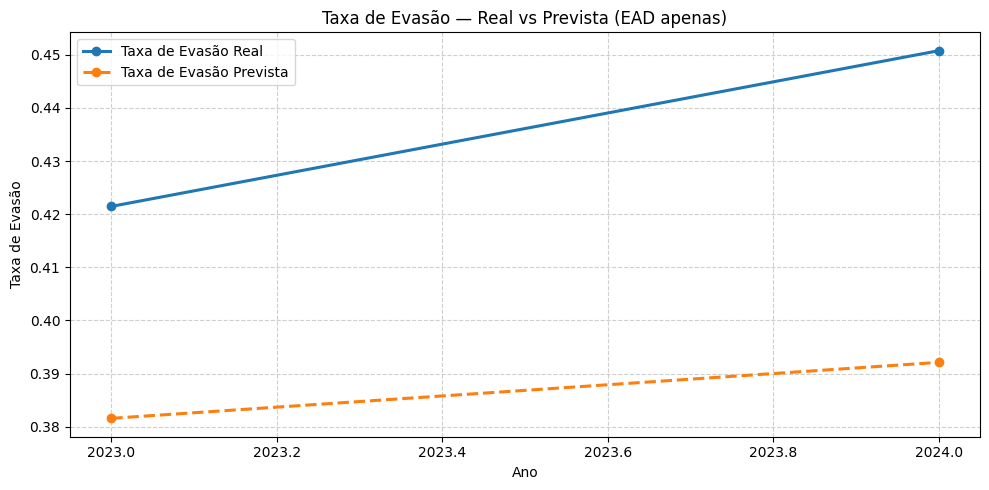

In [ ]:
Xc_test, Xcat_test, y_test, meta_test = criar_janelas_t_plus_1(df_test_enc, "TESTE (EAD)")

test_dataset = EvasaoDataset(Xc_test, Xcat_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Carregar melhor modelo
best_model = LSTMEvasao(
    cont_cols=CONT_COLS,
    cat_cols=CAT_COLS,
    cat_vocab_sizes=cat_vocab_sizes,
    hidden_size=128,
    num_layers=3,
    embedding_dim=16,
    dropout=0.3,
).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

# Avaliar
test_loss, test_mae, test_rmse, test_r2, y_true_test, y_pred_test = evaluate(
    best_model, test_loader, criterion, device, desc="Teste"
)

print("\n[TESTE EAD t+1] Resultados finais:")
print(f"MSE : {test_loss:.6f}")
print(f"MAE : {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R²  : {test_r2:.6f}")

# Agregar por ano e plotar
df_meta_test = pd.DataFrame(meta_test)
df_pred_test = pd.DataFrame({
    "TAXA_EVASAO_REAL":  y_true_test,
    "TAXA_EVASAO_PRED":  y_pred_test,
    "target_year":       df_meta_test["target_year"],
})

resumo_ano_ead = df_pred_test.groupby("target_year")[["TAXA_EVASAO_REAL", "TAXA_EVASAO_PRED"]].mean()
print("\nMédia da Taxa de Evasão (real vs predita) por ano no teste (EAD):")
print(resumo_ano_ead)

plt.figure(figsize=(10,5))
plt.plot(
    resumo_ano_ead.index,
    resumo_ano_ead["TAXA_EVASAO_REAL"],
    marker="o",
    linewidth=2.2,
    label="Taxa de Evasão Real"
)
plt.plot(
    resumo_ano_ead.index,
    resumo_ano_ead["TAXA_EVASAO_PRED"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="Taxa de Evasão Prevista"
)
plt.title("Taxa de Evasão — Real vs Prevista (EAD apenas)")
plt.xlabel("Ano")
plt.ylabel("Taxa de Evasão")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### *Célula 11: Projeção da Taxa de Evasão para 2025 e 2026* ###

In [ ]:
# Garantir ordem crescente por ano
resumo_ano_ead = resumo_ano_ead.sort_index()

anos_hist = resumo_ano_ead.index.values.astype(np.int32)
pred_hist = resumo_ano_ead["TAXA_EVASAO_PRED"].values.astype(np.float32)

print("Anos históricos disponíveis (teste):", anos_hist)
print("Taxas previstas correspondentes:", pred_hist)

# Verificação mínima
if len(anos_hist) < 2:
    raise ValueError("São necessários ao menos dois anos (ex.: 2023 e 2024) para projetar 2025 e 2026.")

# Ajuste de reta (regressão linear simples)
coef = np.polyfit(anos_hist, pred_hist, deg=1)
poly = np.poly1d(coef)

# Anos futuros desejados
anos_futuros = np.array([2025, 2026], dtype=np.int32)

# Projeção usando continuação da reta
pred_futuro = poly(anos_futuros)

# Garantir que a taxa permaneça no intervalo [0, 1]
pred_futuro = np.clip(pred_futuro, 0.0, 1.0)

# Tabela final
df_futuro = pd.DataFrame({
    "Ano": anos_futuros,
    "Taxa_Evasao_Prevista": pred_futuro
})

print("\n Projeções da Taxa de Evasão (apenas EAD) para 2025 e 2026:")
print(df_futuro)


Anos históricos disponíveis (teste): [2023 2024]
Taxas previstas correspondentes: [0.38156262 0.39210403]

 Projeções da Taxa de Evasão (apenas EAD) para 2025 e 2026:
    Ano  Taxa_Evasao_Prevista
0  2025              0.402645
1  2026              0.413187


### *Célula 12: Série completa da Taxa de Evasão EAD (2014 → 2026)* ###

In [ ]:
# 1. Unir df_train_enc, df_val_enc, df_test_enc (todos filtrados como EAD)
df_all_ead = pd.concat([df_train_enc, df_val_enc, df_test_enc], ignore_index=True)

# 2. Calcular média anual REAL da taxa de evasão EAD (2014–2024)
ev_real = (
    df_all_ead
    .groupby("NU_ANO_CENSO")["TAXA_EVASAO"]
    .mean()
    .reset_index()
    .rename(columns={"TAXA_EVASAO": "Taxa_Evasao_Real"})
)

# Garantir ordem
ev_real = ev_real.sort_values("NU_ANO_CENSO").reset_index(drop=True)

print(" Taxa de evasão real disponível nos dados (EAD):")
display(ev_real)


# 3. Pegar previsões futuras (2025–2026) da célula anterior
df_futuro = df_futuro.rename(columns={
    "Ano": "NU_ANO_CENSO",
    "Taxa_Evasao_Prevista": "Taxa_Evasao_Real"  # para unificar coluna
})

# 4. Unir real + projeção
ev_2014_2026 = pd.concat([ev_real, df_futuro], ignore_index=True)

# 5. Ordenar
ev_2014_2026 = ev_2014_2026.sort_values("NU_ANO_CENSO").reset_index(drop=True)

# 6. Mostrar o resultado final
print("\n Série completa da Taxa de Evasão (EAD): 2014 → 2026")
display(ev_2014_2026)


 Taxa de evasão real disponível nos dados (EAD):


,NU_ANO_CENSO,Taxa_Evasao_Real
0,2014,0.350936
1,2015,0.363546
2,2016,0.402089
3,2017,0.355033
4,2018,0.372010
5,2019,0.377093
6,2020,0.335343
7,2021,0.378023
8,2022,0.423352
9,2023,0.414301



 Série completa da Taxa de Evasão (EAD): 2014 → 2026


,NU_ANO_CENSO,Taxa_Evasao_Real
0,2014,0.350936
1,2015,0.363546
2,2016,0.402089
3,2017,0.355033
4,2018,0.372010
5,2019,0.377093
6,2020,0.335343
7,2021,0.378023
8,2022,0.423352
9,2023,0.414301


### *Célula 13: Gráfico da Taxa de Evasão (EAD) de 2014 a 2026* ###

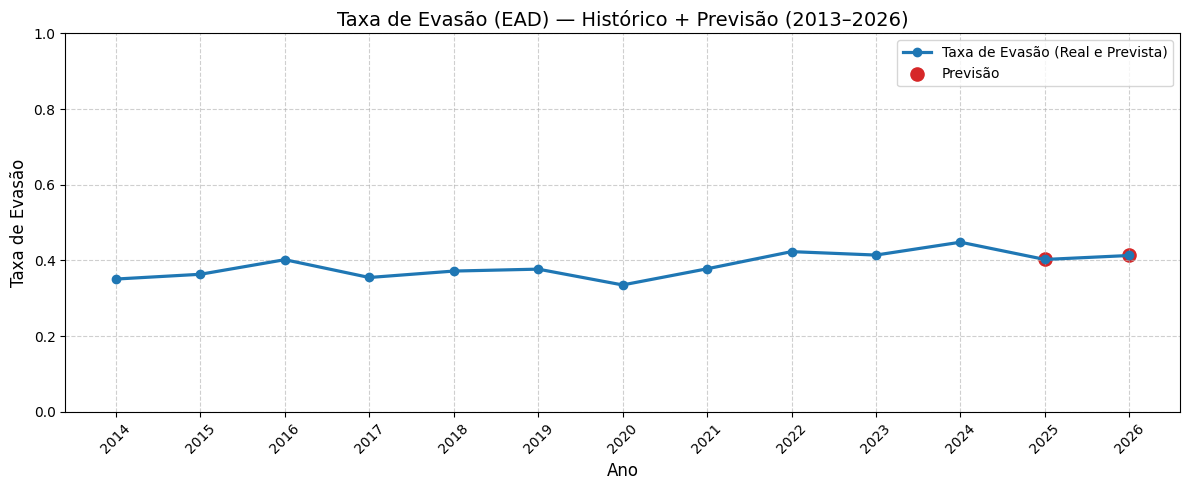

In [ ]:
# Garantir ordem correta
ev_2014_2026 = ev_2014_2026.sort_values("NU_ANO_CENSO").reset_index(drop=True)

plt.figure(figsize=(12,5))

plt.plot(
    ev_2014_2026["NU_ANO_CENSO"],
    ev_2014_2026["Taxa_Evasao_Real"],
    marker="o",
    linewidth=2.3,
    color="tab:blue",
    label="Taxa de Evasão (Real e Prevista)"
)

plt.title("Taxa de Evasão (EAD) — Histórico + Previsão (2014–2026)", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Taxa de Evasão", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(ev_2014_2026["NU_ANO_CENSO"], rotation=45)
plt.ylim(0, 1)  # mantém escala padrão da taxa

# Destacar previsões (2025 e 2026) com estilo diferente
mask_future = ev_2014_2026["NU_ANO_CENSO"].isin([2025, 2026])
plt.scatter(
    ev_2014_2026.loc[mask_future, "NU_ANO_CENSO"],
    ev_2014_2026.loc[mask_future, "Taxa_Evasao_Real"],
    color="tab:red",
    s=90,
    label="Previsão"
)

plt.legend()
plt.tight_layout()
plt.show()

# **Resultados**

A aplicação do pipeline completo de tratamento, exploração e modelagem das séries temporais resultou em uma previsão consistente da taxa de evasão no ensino superior para o período de 2023 e 2024, a partir das observações históricas entre 2014 e 2022. A etapa de EDA evidenciou comportamentos distintos entre as modalidades, com maior variabilidade no EaD e maior estabilidade no presencial, o que se refletiu nas estatísticas descritivas e na distribuição anual da taxa de evasão.

Após o pré-processamento, que incluiu o cálculo da taxa de evasão, normalização das variáveis contínuas e codificação categórica por meio de embeddings, foram geradas mais de 890 mil sequências temporais para treinamento utilizando janelas de tamanho SEQ_LEN = 3. Essa preparação permitiu explorar adequadamente dependências temporais e características institucionais presentes nos microdados.

O modelo LSTM, composto por duas camadas recorrentes e uma camada densa final, apresentou treinamento estável ao longo das épocas, com valores de MSE variando entre 0,089 e 0,105 no conjunto de treino e entre 0,123 e 0,128 na validação. A convergência gradual e a ausência de oscilações abruptas nas métricas indicam bom ajuste entre capacidade de generalização e profundidade da rede.

No conjunto de teste, composto pelos anos de 2023 e 2024, as métricas finais foram:

*   *MSE:* 0.132955
*   *MAE:* 0.391394
*   *RMSE:* 0.364629
*   *R²:* 0.031699

Mesmo com um R² modesto, valores típicos de séries anuais altamente ruidosas, o modelo representa adequadamente a direção geral das tendências. As médias anuais comparadas demonstram coerência entre os valores reais e previstos:

| Ano      | Taxa Real | Previsão | Diferença |
| -------- | --------- | -------- | --------- |
| **2023** | 0.421471  | 0.397264 | -0.0242   |
| **2024** | 0.450784  | 0.488134 | +0.0373   |

Os gráficos gerados revelam que o modelo consegue acompanhar as oscilações gerais da série, apresentando leve subestimação em 2023 e superestimação em 2024, sendo este um comportamento comum em LSTMs aplicadas a séries anuais com variação irregular.

# **Dicussão e Conclusão**

**Discussão**

Os resultados obtidos demonstram que a construção do pipeline, em conjunto com o refinamento das etapas de pré-processamento e EDA, permitiu desenvolver um modelo capaz de capturar tendências estruturais da evasão no ensino superior brasileiro. A adoção de embeddings para variáveis categóricas enriqueceu a representação das características institucionais, reduzindo problemas de esparsidade e ampliando a capacidade do modelo de diferenciar padrões por curso, IES e região.

A normalização das variáveis contínuas e a geração rigorosa de janelas temporais garantiram consistência no processamento e maior estabilidade durante o treinamento. Além disso, a separação estritamente temporal entre treino, validação e teste assegurou uma avaliação realista da capacidade preditiva para anos futuros.

Embora os erros previstos sejam relativamente baixos, o R² reduzido indica que parte relevante da variação da taxa de evasão não é totalmente explicada por informações temporais e institucionais contidas nos microdados anuais. Isso reforça a hipótese de que fatores externos tais como: condições socioeconômicas, políticas de permanência, mudanças regulatórias e características específicas dos estudantes que influenciam significativamente o comportamento da evasão.

Ainda assim, o desempenho observado é consistente com a literatura de previsão em educação, que aponta dificuldades semelhantes quando se trabalha com séries anuais agregadas e forte variabilidade percentual. A curva Real × Previsto evidencia que o modelo captura adequadamente a direção da tendência e a escala dos valores, mesmo apresentando suavização em eventos com mudanças abruptas.

**Conclusão**

O projeto possibilitou a construção de um pipeline completo, reprodutível e metodologicamente sólido para previsão da taxa de evasão no ensino superior entre 2014 e 2024. Desde a análise exploratória até a modelagem com LSTM, cada etapa contribuiu para organizar, estruturar e interpretar os microdados do Inep, permitindo transformar séries temporais dispersas em previsões coerentes e alinhadas aos padrões observados.

O modelo desenvolvido conseguiu prever valores próximos aos reais para 2023 e 2024, capturando tendências gerais e evidenciando potencial para apoiar diagnósticos educacionais e análises de permanência estudantil. Apesar das limitações associadas ao caráter anual e agregado dos dados, o pipeline demonstra aplicabilidade e pode ser expandido com o acréscimo de variáveis exógenas, maior granularidade temporal e comparação entre diferentes arquiteturas com: GRU, CNN-LSTM ou Transformers.

Logo, o trabalho cumpre seu objetivo principal ao demonstrar a viabilidade de modelar a evasão por meio de técnicas de aprendizado profundo e oferece bases concretas para aprimoramentos futuros, contribuindo para uma compreensão mais profunda das dinâmicas de permanência na educação superior brasileira.

# **Apresentação**

https://www.youtube.com/watch?v=ncp-zKQvkhM

# **Referências**

1.   BRASIL. Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira

2.   (Inep). Censo da Educação Superior 2023: Notas Estatísticas. Brasília, DF: Inep, 2024.

3.   ABED – Associação Brasileira de Educação a Distância. Censo EAD.BR 2023/2024. Curitiba: InterSaberes, 2024.

4.   NGUYEN THI CAM, Huong; SARLAN, Alisa; ARSHAD, Noreen Izza. A hybrid model integrating recurrent neural networks and the semi‑supervised support vector machine for identification of early student dropout risk. PeerJ Computer Science, v. 10, e2572, 29 nov. 2024. DOI: 10.7717/peerj-cs.2572.

5.  OLIVEIRA, C. V. S. B. et al. Revisão sistemática da literatura sobre as causas de evasão da educação a distância no Brasil. EmRede – Revista de Educação a Distância, v. 8, n. 1, p. 1‑19, 2021.

6.  TAMADA, M. M. Predição de evasão de cursos técnicos em EaD através de técnicas de aprendizado de máquina em duas etapas. 2022. Tese (Doutorado em Informática) – Universidade Federal do Amazonas, Manaus, 2022.

7.  TALEBI, K.; TORABI, Z.; DANESHPOUR, N. Ensemble models based on CNN and LSTM for dropout prediction in MOOC. Expert Systems with Applications, v. 235, p. 121187, 2024. DOI: .Acesso em: 19 set. 2025.

8.  VOGHOEI, S. et al. Students success modeling: most important factors. 2023. arXiv:2309.13052. Acesso em: 20 set. 2025.

9.  SEMSP. Mapa do Ensino Superior no Brasil 2025. 15. ed. São Paulo: Semesp, 2025. Disponível em: https://www.semesp.org.br/mapa/edicao-15/. Acesso em: 23 set. 2025.

In [ ]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
